## Settings and imports

In [4]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

In [5]:
real_or_simulated = 'real' #simulated / real / all
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False
augmentation = True

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [8]:
data_path = '../data/DANE.xlsx'

In [9]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

## Preprocessing

### Some checks on the data

1. Let's check if column naming is consistent (inDs).

In [10]:
series_based_on_sample_name = pd.Series(inds_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [11]:
series_based_on_column = inds_df['seria'].reset_index(drop=True)

In [12]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything is fine. For inKs:

In [13]:
series_based_on_sample_name = pd.Series(inks_df.index).apply(
                                lambda x: x[:-2] if x[-2].isdigit() else x[:-1]).reset_index(drop=True)

In [14]:
series_based_on_column = inks_df['seria'].reset_index(drop=True)

In [15]:
np.all(series_based_on_column == series_based_on_sample_name)

True

Everything ok.

2. Let's check if naming is consistent across two sheets (i.e. for inDs and for inKs).

In [16]:
series_from_inds_sheet = inds_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [17]:
series_from_inks_sheet = inks_df['seria'].apply(lambda x: x[:-1]).reset_index(drop=True)

In [18]:
np.all(series_from_inds_sheet == series_from_inks_sheet)

False

It's not consistent, but it's not the problem, cause rows in both tables correspond to each other.

In [19]:
inks_df.shape == inds_df.shape

True

### Joining corresponding samples from inds and inks into one table

In [20]:
inks_df = inks_df.reset_index(drop=False)

In [21]:
inds_df = inds_df.reset_index(drop=False)

In [22]:
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

In [23]:
# with pd.option_context("display.max_rows", inDKs_df.shape[0]):
#     display(inDKs_df[['nazwa próbki_inds', 'nazwa próbki_inks']][
#                 (inDKs_df['nazwa próbki_inds'].apply(
#                         lambda x: x[:4]) != inDKs_df['nazwa próbki_inks'].apply(
#                                         lambda x: x[:4]))
#                                                         ])

### Removing some data

1. Let's remove rows with missing values.

In [24]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.047337278106508875

In [25]:
inDKs_df.dropna(inplace=True)

In [26]:
inDKs_df.shape

(2415, 64)

2. Let's keep only columns that we need.

In [27]:
inks_colnames = [col for col in inDKs_df.columns if (col.endswith('_inks') and 
                                                     col != 'nazwa próbki_inks'and
                                                    col != 'seria_inks' and
                                                    col != 'Fe_inks')]
inds_colnames = [col for col in inDKs_df.columns if (col.endswith('_inds') and 
                                                     col != 'nazwa próbki_inds'and
                                                    col != 'seria_inds' and
                                                    col != 'Fe_inds')]
#no iron because it's a reference element

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

If you want to keep use version with 29 numbers, just comment out the cell below.

In [28]:
inks_colnames = [
 'Al_inks',
 'S_inks',
 'Cr_inks',
 'Mn_inks',
 'Co_inks',
 'Cu_inks',
 'Zn_inks',
 'Pb_inks']

inds_colnames = [
 'Al_inds',
 'S_inds',
 'Cr_inds',
 'Mn_inds',
 'Co_inds',
 'Cu_inds',
 'Zn_inds',
 'Pb_inds']

### Creating features and labels matrices

In [29]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [30]:
X = np.array(inDKs_df[inds_colnames].values)
y = np.array(inDKs_df[inks_colnames].values)

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

### Normalization

In [31]:
X = (X - np.mean(X, axis=0))/np.std(X, axis=0)
y = (y - np.mean(y, axis=0))/np.std(y, axis=0)

### Converting to tensors

In [32]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [33]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [34]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [35]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [36]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [37]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [38]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=True)

## Building neural network

In [39]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [40]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [41]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=8, bias=True)
  )
)


In [42]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [43]:
weights = torch.tensor([1/2,1/4,1/8,1/40,1/40,1/40,1/40,1/40]).unsqueeze(1).to(device)

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [44]:
# loss = F.l1_loss(torch.t(torch.mul(torch.t(forecast), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))) ,
#                          torch.t(torch.mul(torch.t(torch.tensor(target,dtype=torch.float).to(DEVICE)), 
#                                            torch.tensor(weight,dtype=torch.float).to(DEVICE))),reduction='mean')
# loss.backward()
# params.append(net.parameters())
# optimiser.step()

In [45]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 0.43085331122080484 test 0.45099619103452926
EPOCH 2:
LOSS train 0.42890814542770384 test 0.4466901254024565
EPOCH 3:
LOSS train 0.4242812514305115 test 0.4423858426033093
EPOCH 4:
LOSS train 0.41850111484527586 test 0.4380967818339419
EPOCH 5:
LOSS train 0.4181869705518087 test 0.4338310843113787
EPOCH 6:
LOSS train 0.4086740791797638 test 0.4295644053792114
EPOCH 7:
LOSS train 0.4108117461204529 test 0.42532405266480416
EPOCH 8:
LOSS train 0.4030933976173401 test 0.4210707134650114
EPOCH 9:
LOSS train 0.3972376068433126 test 0.41684512342046753
EPOCH 10:
LOSS train 0.39704843362172443 test 0.4126646350876392
EPOCH 11:
LOSS train 0.3939635992050171 test 0.40850441312074165
EPOCH 12:
LOSS train 0.3924379010995229 test 0.4043184207679075
EPOCH 13:
LOSS train 0.3789844890435537 test 0.4000905231566903
EPOCH 14:
LOSS train 0.37618845105171206 test 0.39594466677301915
EPOCH 15:
LOSS train 0.37565073172251384 test 0.39232474119705196
EPOCH 16:
LOSS train 0.37178348501523

LOSS train 0.1772704914212227 test 0.19211547915181665
EPOCH 129:
LOSS train 0.1687697430451711 test 0.19189033234842878
EPOCH 130:
LOSS train 0.1690127154191335 test 0.19167597536151884
EPOCH 131:
LOSS train 0.16950825502475103 test 0.191448204708141
EPOCH 132:
LOSS train 0.169100817044576 test 0.19121333481126906
EPOCH 133:
LOSS train 0.16797722627719244 test 0.19103278520114056
EPOCH 134:
LOSS train 0.1766267627477646 test 0.19080899245256083
EPOCH 135:
LOSS train 0.17156821936368943 test 0.19057257012531592
EPOCH 136:
LOSS train 0.17268875340620676 test 0.19034723140970336
EPOCH 137:
LOSS train 0.17182159870862962 test 0.1901128674779226
EPOCH 138:
LOSS train 0.16832225074370702 test 0.18986475684797666
EPOCH 139:
LOSS train 0.16624313195546467 test 0.18962311355674766
EPOCH 140:
LOSS train 0.17153602987527847 test 0.1894035266816431
EPOCH 141:
LOSS train 0.1677863617738088 test 0.1891631743905383
EPOCH 142:
LOSS train 0.16649121741453807 test 0.18891141508796538
EPOCH 143:
LOSS tr

LOSS train 0.15599271257718403 test 0.17259429825091924
EPOCH 253:
LOSS train 0.15803441107273103 test 0.17251360606629687
EPOCH 254:
LOSS train 0.15525977065165839 test 0.17246103131908375
EPOCH 255:
LOSS train 0.1579290434718132 test 0.17237868981231505
EPOCH 256:
LOSS train 0.15215842028458912 test 0.17232324288652798
EPOCH 257:
LOSS train 0.15799952199061712 test 0.1722763007155795
EPOCH 258:
LOSS train 0.15365730971097946 test 0.17223053285273612
EPOCH 259:
LOSS train 0.15417108684778214 test 0.17216044806684397
EPOCH 260:
LOSS train 0.15346579551696776 test 0.17212039310442703
EPOCH 261:
LOSS train 0.1619242971142133 test 0.1720919956069432
EPOCH 262:
LOSS train 0.15562138110399246 test 0.172045030603166
EPOCH 263:
LOSS train 0.15237036297718684 test 0.17198570537830146
EPOCH 264:
LOSS train 0.15148726627230644 test 0.17194046173823177
EPOCH 265:
LOSS train 0.15557846575975418 test 0.17187856068240775
EPOCH 266:
LOSS train 0.1531873069703579 test 0.17179732741768747
EPOCH 267:
LO

LOSS train 0.1458081766963005 test 0.16387606039739697
EPOCH 377:
LOSS train 0.1462668443719546 test 0.16379870590127188
EPOCH 378:
LOSS train 0.1500529666741689 test 0.16368708667763765
EPOCH 379:
LOSS train 0.14515072405338286 test 0.16359386408092227
EPOCH 380:
LOSS train 0.14544960657755535 test 0.16354168656978207
EPOCH 381:
LOSS train 0.14616951048374177 test 0.1634865310708327
EPOCH 382:
LOSS train 0.1457434778412183 test 0.16336697632134517
EPOCH 383:
LOSS train 0.144986921052138 test 0.1633347054166376
EPOCH 384:
LOSS train 0.14931060026089352 test 0.16323797480062452
EPOCH 385:
LOSS train 0.15077360918124516 test 0.1631606771373508
EPOCH 386:
LOSS train 0.14751394018530845 test 0.16306960497795764
EPOCH 387:
LOSS train 0.14492155611515045 test 0.16302403325396234
EPOCH 388:
LOSS train 0.14852655033270518 test 0.16297450999962648
EPOCH 389:
LOSS train 0.1521056264638901 test 0.1629103426956504
EPOCH 390:
LOSS train 0.14655733903249105 test 0.1627892619789449
EPOCH 391:
LOSS tr

LOSS train 0.1415250038107236 test 0.15601349630688102
EPOCH 501:
LOSS train 0.1440957282980283 test 0.1559620628019652
EPOCH 502:
LOSS train 0.14444999694824218 test 0.15590540032378758
EPOCH 503:
LOSS train 0.14484425236781437 test 0.1558622758552108
EPOCH 504:
LOSS train 0.14092210133870442 test 0.15582002953801682
EPOCH 505:
LOSS train 0.14284848322470983 test 0.15578052293948874
EPOCH 506:
LOSS train 0.14356273810068768 test 0.1557832855825731
EPOCH 507:
LOSS train 0.14049285451571147 test 0.15576632408035715
EPOCH 508:
LOSS train 0.1409344991048177 test 0.15569986649798556
EPOCH 509:
LOSS train 0.14016589820384978 test 0.15570214095739474
EPOCH 510:
LOSS train 0.14292712410291036 test 0.15568929528007688
EPOCH 511:
LOSS train 0.14214970171451569 test 0.15565775912717816
EPOCH 512:
LOSS train 0.1436918020248413 test 0.15560834813866894
EPOCH 513:
LOSS train 0.1416378900408745 test 0.1556067484243933
EPOCH 514:
LOSS train 0.14164885580539704 test 0.15563711668528601
EPOCH 515:
LOSS

...

LOSS train 0.11495380153258641 test 0.12793482035903672
EPOCH 4417:
LOSS train 0.11899604896704356 test 0.1279919040919615
EPOCH 4418:
LOSS train 0.11542174518108368 test 0.12789457430773826
EPOCH 4419:
LOSS train 0.11925915479660035 test 0.12795365946926562
EPOCH 4420:
LOSS train 0.12094549611210823 test 0.1279398484895966
EPOCH 4421:
LOSS train 0.121234001715978 test 0.12782426605552558
EPOCH 4422:
LOSS train 0.11606657554705938 test 0.12793794989308216
EPOCH 4423:
LOSS train 0.11455806245406469 test 0.12788323591526898
EPOCH 4424:
LOSS train 0.11771968106428782 test 0.12792930918250148
EPOCH 4425:
LOSS train 0.11517919699350992 test 0.12790842017343973
EPOCH 4426:
LOSS train 0.11679190248250962 test 0.1278754405775657
EPOCH 4427:
LOSS train 0.11612301766872406 test 0.1279081487256887
EPOCH 4428:
LOSS train 0.11658792744080225 test 0.12796535957932442
EPOCH 4429:
LOSS train 0.11898167828718821 test 0.1278737380369865
EPOCH 4430:
LOSS train 0.1151863103111585 test 0.1280052698685886
E

LOSS train 0.11729700540502866 test 0.1276366510785206
EPOCH 4539:
LOSS train 0.11711260279019674 test 0.1277385964694647
EPOCH 4540:
LOSS train 0.11525791883468628 test 0.12760595176426798
EPOCH 4541:
LOSS train 0.11478030135234198 test 0.12766330808740473
EPOCH 4542:
LOSS train 0.11460892210404078 test 0.1276252540001958
EPOCH 4543:
LOSS train 0.11619440913200378 test 0.12756983518473203
EPOCH 4544:
LOSS train 0.11528892914454142 test 0.12771809669346482
EPOCH 4545:
LOSS train 0.11782694359620412 test 0.12764170606896344
EPOCH 4546:
LOSS train 0.11469218184550603 test 0.12754022935598194
EPOCH 4547:
LOSS train 0.11533913984894753 test 0.12761026902768305
EPOCH 4548:
LOSS train 0.11663398444652558 test 0.12761671350802262
EPOCH 4549:
LOSS train 0.11631078720092773 test 0.12761411261715874
EPOCH 4550:
LOSS train 0.11517566094795863 test 0.12760465128316426
EPOCH 4551:
LOSS train 0.11745744322737058 test 0.12765320198702979
EPOCH 4552:
LOSS train 0.11554876317580541 test 0.1276160638526

LOSS train 0.11440274839599927 test 0.1272726454212876
EPOCH 4661:
LOSS train 0.1162923996647199 test 0.12725278850563843
EPOCH 4662:
LOSS train 0.11734112749497096 test 0.12724923779590222
EPOCH 4663:
LOSS train 0.11466416468222936 test 0.12727472774287218
EPOCH 4664:
LOSS train 0.11508396615584691 test 0.127416408226457
EPOCH 4665:
LOSS train 0.11400519236922264 test 0.1273046839648692
EPOCH 4666:
LOSS train 0.1189515769481659 test 0.1272291649512823
EPOCH 4667:
LOSS train 0.11734872410694758 test 0.12740752354021306
EPOCH 4668:
LOSS train 0.1151687333981196 test 0.1272669888061026
EPOCH 4669:
LOSS train 0.11602020114660264 test 0.12726770106926716
EPOCH 4670:
LOSS train 0.11514925211668015 test 0.12726475880240276
EPOCH 4671:
LOSS train 0.11775306438406309 test 0.12735432320839377
EPOCH 4672:
LOSS train 0.11745736797650655 test 0.12741032346223113
EPOCH 4673:
LOSS train 0.11726345072189967 test 0.12726475389223108
EPOCH 4674:
LOSS train 0.12229495321710905 test 0.12730236932072272
E

LOSS train 0.11693443904320398 test 0.12687284441271462
EPOCH 4783:
LOSS train 0.1151667724053065 test 0.12700932198946457
EPOCH 4784:
LOSS train 0.11432061170538267 test 0.1269506969591352
EPOCH 4785:
LOSS train 0.11774781470497449 test 0.12687660996584263
EPOCH 4786:
LOSS train 0.11612648069858551 test 0.12696883321679958
EPOCH 4787:
LOSS train 0.11565772121151288 test 0.12691410251663646
EPOCH 4788:
LOSS train 0.1141381027797858 test 0.1269412525480239
EPOCH 4789:
LOSS train 0.11493654946486155 test 0.1269338465002645
EPOCH 4790:
LOSS train 0.11770466988285383 test 0.12693604930375335
EPOCH 4791:
LOSS train 0.11507162501414617 test 0.12692632479111107
EPOCH 4792:
LOSS train 0.11442209010322889 test 0.12698646846823164
EPOCH 4793:
LOSS train 0.11683739721775055 test 0.12682875173405492
EPOCH 4794:
LOSS train 0.12084808746973673 test 0.12695648966503656
EPOCH 4795:
LOSS train 0.11466439664363862 test 0.12685931375149953
EPOCH 4796:
LOSS train 0.11586460868517558 test 0.126934308746702

LOSS train 0.11569561511278152 test 0.12666576441500807
EPOCH 4905:
LOSS train 0.11878628333409627 test 0.12658251457274977
EPOCH 4906:
LOSS train 0.11490834876894951 test 0.12660812007120617
EPOCH 4907:
LOSS train 0.11460358649492264 test 0.12656840758965068
EPOCH 4908:
LOSS train 0.11497585127751032 test 0.1265393481580213
EPOCH 4909:
LOSS train 0.11594156076510748 test 0.1268001000317851
EPOCH 4910:
LOSS train 0.1159561331073443 test 0.1265203337470459
EPOCH 4911:
LOSS train 0.11553056836128235 test 0.12653523235144112
EPOCH 4912:
LOSS train 0.11501712476213773 test 0.12667656146803596
EPOCH 4913:
LOSS train 0.11639128724733988 test 0.12660424971536544
EPOCH 4914:
LOSS train 0.11844350298245748 test 0.12656630333667276
EPOCH 4915:
LOSS train 0.11544501483440399 test 0.12663119522214522
EPOCH 4916:
LOSS train 0.11446481049060822 test 0.12655378687127994
EPOCH 4917:
LOSS train 0.11908364196618398 test 0.12661053358401725
EPOCH 4918:
LOSS train 0.11464151591062546 test 0.12654191776666

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

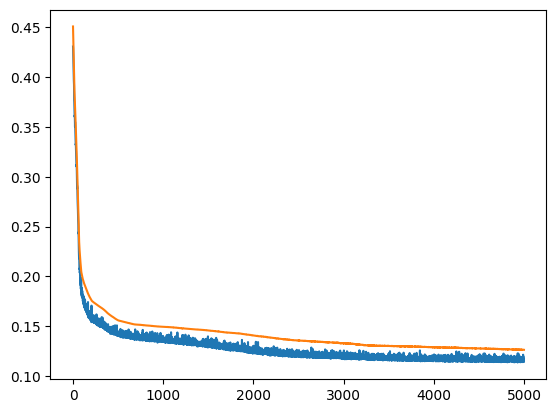

In [46]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, weights [1/2, 1/4, 1/8, 1/40, ...]
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

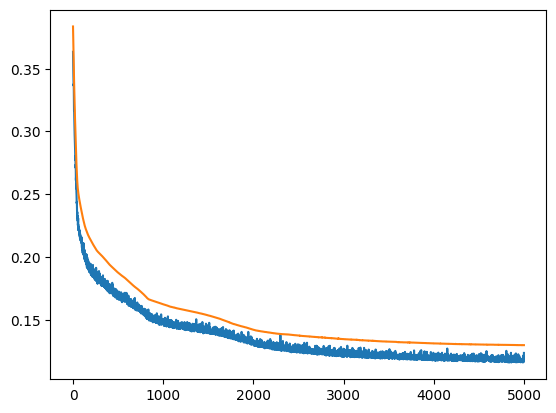

In [43]:
#no keeping one sample together
#4 layers each 8 neurons, custom loss, equal weights
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

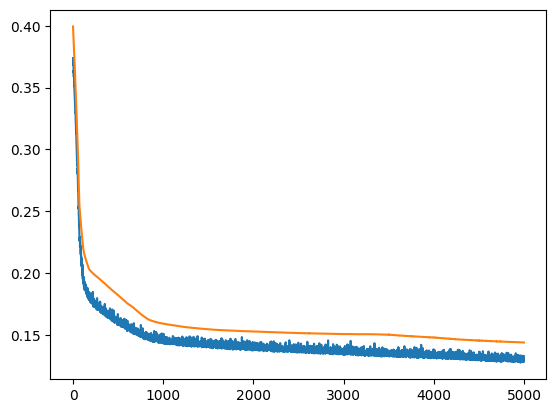

In [41]:
#no keeping one sample together
#4 layers each 8 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

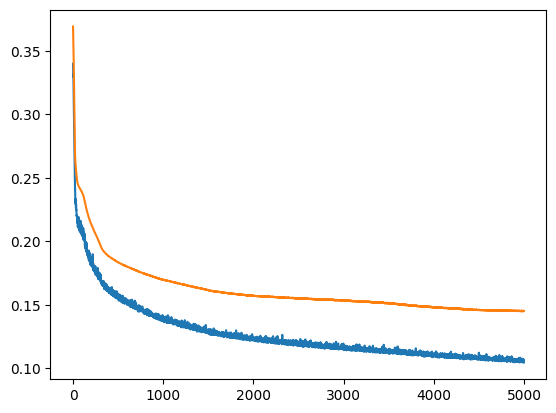

In [41]:
#no keeping one sample together
#4 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

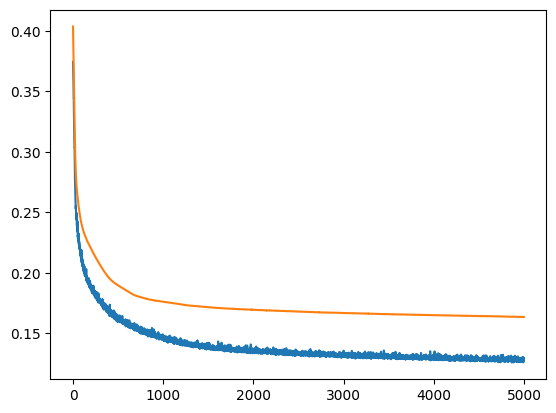

In [38]:
#no keeping one sample together
#2 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

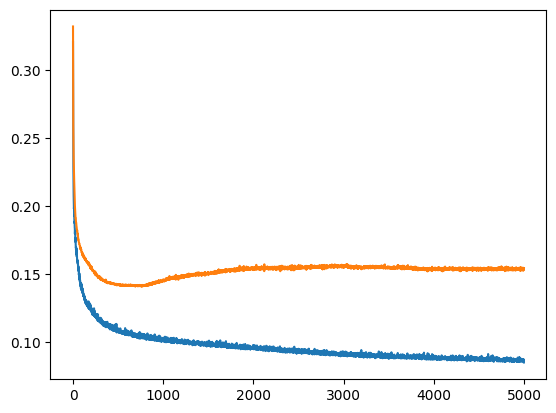

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.001

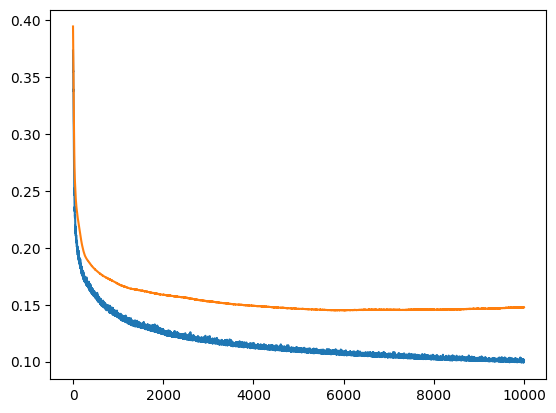

In [38]:
#no keeping one sample together
#3 layers each 29 neurons
plt.plot(train_losses) #real
plt.plot(val_losses) #lr=0.0001

## Test set

In [47]:
model.eval()
running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    res = torch.concat((res, abs(outputs-labels)), axis=0)
    lab = torch.concat((lab, labels), axis=0)
    out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [48]:
lab

tensor([[-0.2553, -0.1043, -0.1699,  ..., -0.0737, -0.1847, -0.0897],
        [-0.2553, -0.1043, -0.1699,  ..., -0.0737, -0.1847, -0.0897],
        [-0.2893,  0.6505, -0.0942,  ..., -0.0735, -0.2246, -0.0902],
        ...,
        [-0.2619, -0.1439, -0.1698,  ..., -0.0738, -0.1673, -0.0877],
        [-0.1116, -0.0649, -0.1693,  ..., -0.0735, -0.2037, -0.0145],
        [-0.2663, -0.1537, -0.1699,  ..., -0.0737, -0.2108, -0.0792]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [49]:
out

tensor([[-0.2666, -0.1160, -0.1705,  ..., -0.0734, -0.1774, -0.0920],
        [-0.2666, -0.1160, -0.1705,  ..., -0.0734, -0.1774, -0.0920],
        [-0.2913,  0.4216, -0.1248,  ..., -0.0711, -0.0541, -0.0969],
        ...,
        [-0.1838, -0.1415, -0.1701,  ..., -0.0733, -0.1809, -0.0807],
        [-0.1730, -0.0824, -0.1436,  ..., -0.0736,  0.0181,  0.0106],
        [-0.2776, -0.1551, -0.1781,  ..., -0.0677, -0.2164, -0.1574]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [50]:
res

tensor([[1.1268e-02, 1.1774e-02, 6.6839e-04,  ..., 3.1840e-04, 7.2889e-03,
         2.3358e-03],
        [1.1268e-02, 1.1774e-02, 6.6839e-04,  ..., 3.1840e-04, 7.2889e-03,
         2.3358e-03],
        [1.9777e-03, 2.2890e-01, 3.0610e-02,  ..., 2.3884e-03, 1.7051e-01,
         6.7248e-03],
        ...,
        [7.8044e-02, 2.4049e-03, 3.6503e-04,  ..., 4.7506e-04, 1.3544e-02,
         6.9274e-03],
        [6.1391e-02, 1.7486e-02, 2.5697e-02,  ..., 1.0134e-04, 2.2183e-01,
         2.5079e-02],
        [1.1263e-02, 1.3753e-03, 8.1958e-03,  ..., 6.0362e-03, 5.6624e-03,
         7.8158e-02]], device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [51]:
torch.mean(res, axis=0)

tensor([0.1438, 0.0755, 0.1315, 0.4444, 0.1952, 0.0479, 0.2338, 0.0492],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [ ]:
Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [56]:
torch.mean(res)

tensor(0.1353, device='cuda:0', grad_fn=<MeanBackward0>)

Below: some experiments, visualisations...

In [60]:
dim_nr = 0
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

In [61]:
#torch.max(out, axis=0)

(0.0, 4.0)

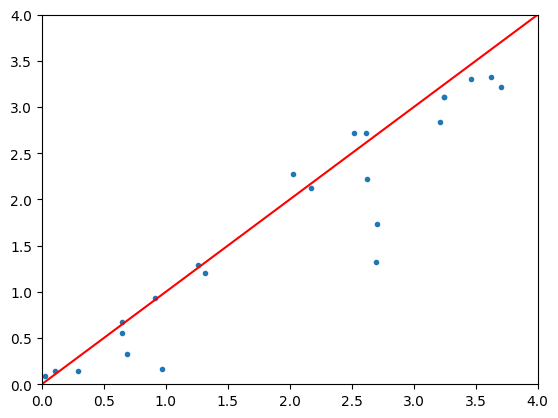

In [62]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [0,20],[0,20], 'red' )
plt.xlim(0, 4)
plt.ylim(0, 4)

In [52]:
torch.mean(res, 0)

tensor([0.1438, 0.0755, 0.1315, 0.4444, 0.1952, 0.0479, 0.2338, 0.0492],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [64]:
mean_loss

0.13389697226871183

## Interpretability

...